# 6.5 Neural Network in Scientific Models (Linear)


In [16]:
using CairoMakie
using LinearAlgebra
using LinearSolve
using SparseArrays
using BenchmarkTools
using ComponentArrays
using CSV
using DataFrames
using Lux
using Random
using Distributions

using Optimization
using Optimisers
using OptimizationOptimisers
using ForwardDiff

As discussed in Chapter 5, many scientific applications can be described in the form of a boundary value problem, 

$\frac{d^2 x}{dt^2} + p(t)\frac{d x}{d t} + q(t)x = r(t)$

$t\in[a,b]$ and you are given the conditionas at $t=a$ and $b$.  Usually we assume that we know  $p(t)$, $q(t)$ and $r(t)$ and you are able to use the techniques I introduced in Chapter 5 to find $x(t)$.  However, in many applications you might not know $p(t)$, $q(t)$ or $r(t)$, but you might have some data or measurements, $x_i$ of $x(t_i)$.  In such cases, we can use a Neural Network to approximate $p(t)$, $q(t)$ or $r(t)$ and use optimisation techniques to tune the parameters of the Neural Network so that the predicted $x(t)$ matches the $x_i$ from the measurements.  After you find your $p(t)$, $q(t)$ or $r(t)$, you can use it in the equation above to predict $x(t)$.  Let's see how this technique might work. 

We will first calculate $x(t_i)$ using a known $r(t)$.   We will then this computed $x(t_i)$ as our data to see if we can get back our $r(t)$.  



![Alt text for screen readers](../figures/06p04TrainingMultivariateNeuralNetworks03.png)

In this example, for simplicity, we will assume that $p(t)=0$ and $q(t)=0$.     Hence, we will consider our governing equation as

$\frac{d^2x}{dt^2}+4x=r(t)$

This model can be thought of as a mass of an object on spring.  This object is initially at $x(t=0)=0$ and we also know that its velocity $dx/dt(t=1)=0$. This object is being pulled by a force $r(t)$, which is high at $t=0$ but then decays away with as $t$ gets larger.  We will assume that $r(t)=2\exp(-t^2)$ and will generate the data using this model.  

Using the finite difference approximation, the mathematical model is


$\frac{x_{i-1}-2x_i+x_{i+1}}{\Delta^2}+4x_i=r(t_i)$ 

This is a linear equation, which we can put in matrix form (assuming you split the domain $t\in[0,1]$ into 5 intervals (6 points))



$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2 +4 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 +4 & 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2 +4& 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 +4 & 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1& 1   \\
\end{bmatrix}\begin{Bmatrix}
x_1\\
x_2\\
x_3\\
x_4\\
x_5\\
x_6\\
\end{Bmatrix}=\begin{Bmatrix}
0\\
r(t_2)\\
r(t_3)\\
r(t_4)\\
r(t_5)\\
0\\
\end{Bmatrix}
$$

Code up this matrix equation

In [2]:
Delta=0.02
tdata=0:Delta:1

n=length(tdata)
d=zeros(n)
dl=zeros(n-1)
du=zeros(n-1)
C_true=zeros(n)
C_model=zeros(n)

du[1]=0.0
d[1]=1.0
C_true[1]=0.0
for i=2:n-1
    dl[i-1]=(1.0/Delta^2)
    d[i]=-(2.0/Delta^2)+4.0
    du[i]=(1.0/Delta^2)
    C_true[i]=2*exp(-tdata[i]*tdata[i])
end
dl[n-1]=-1.0
d[n]=1.0
C_true[n]=0.0

# Construct the specialized structured matrix
A = Tridiagonal(dl, d, du)
prob=LinearProblem(A,C_true)
@time xdata=LinearSolve.solve(prob)

  3.084397 seconds (18.47 M allocations: 946.080 MiB, 16.45% gc time, 100.00% compilation time)


retcode: Success
u: 51-element Vector{Float64}:
 5.2580162446247416e-14
 0.026746187123343226
 0.05424926041122799
 0.08246425590590889
 0.11134443376892514
 0.14084135688701444
 0.17090497370108382
 0.20148370510452943
 0.23252453524476974
 0.2639731060498999
 ⋮
 1.1437191154286277
 1.154471476656328
 1.163758527360787
 1.1715523486504378
 1.177827572635226
 1.1825614376227414
 1.1857338382122762
 1.1873273701970326
 1.1873273701970324

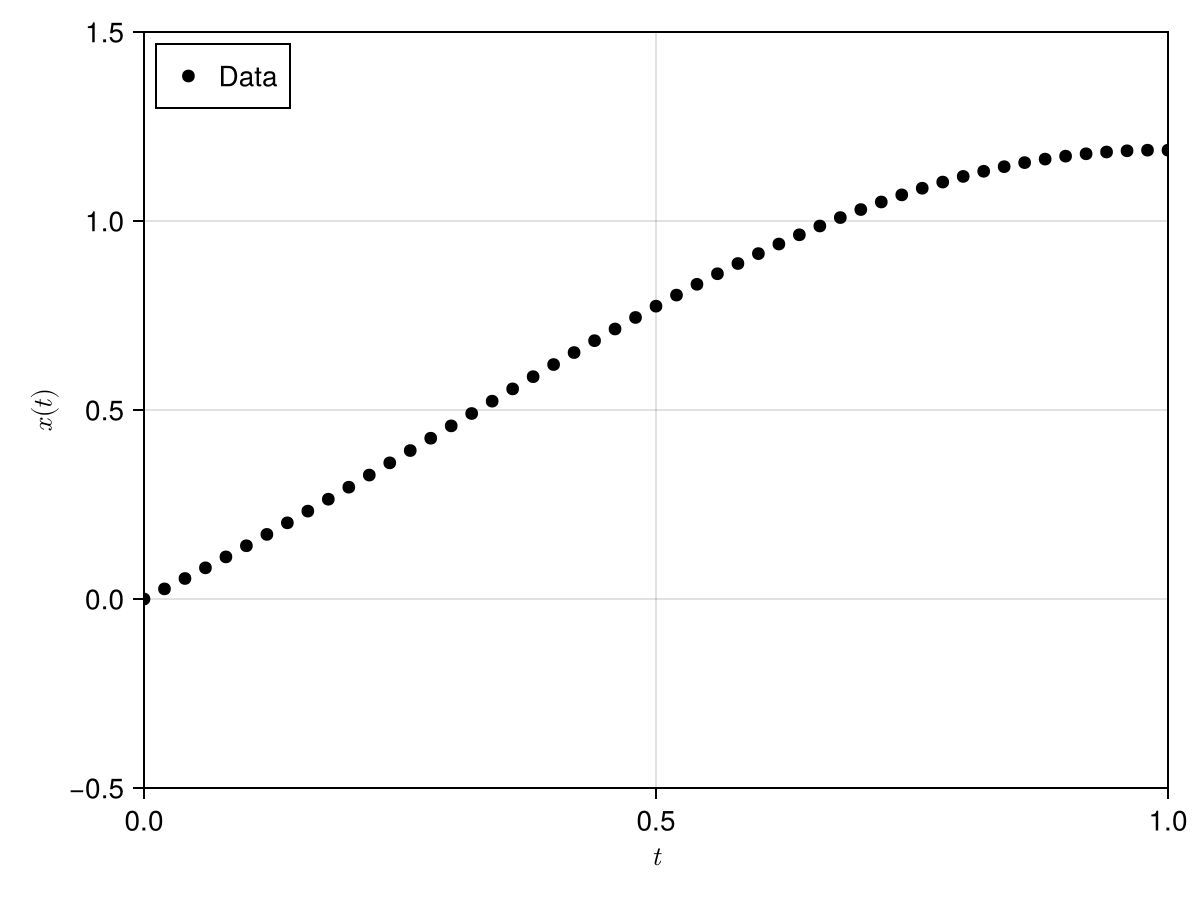

In [3]:
fig = Figure(backgroundcolor=:transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)",limits=(0, 1, -0.5, 1.5),backgroundcolor=:transparent)
scatter!(ax,tdata,xdata,color=:black,label="Data")
#save("../figures/06p05NeuralNetworkScientificModels01.png",fig)
axislegend(ax,position=:lt)
fig

---

We will now assume that we do not know $r(t)$.  We will replace $r(t)$ with a Neural Network.  Then tune the coefficients of the Neural Network so that we will minimise the error between prediction and the dataset.  


$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2 +4 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 +4 & 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2 +4& 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 +4 & 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1& 1   \\
\end{bmatrix}\begin{Bmatrix}
x_1\\
x_2\\
x_3\\
x_4\\
x_5\\
x_6\\
\end{Bmatrix}=\begin{Bmatrix}
0\\
NN(t_2)\\
NN(t_3)\\
NN(t_4)\\
NN(t_5)\\
0\\
\end{Bmatrix}
$$

Setting up the  Neural Network model for $r(t)=NN(t)$

In [4]:
rng=Xoshiro(1) 

RModel = Chain(Dense(1 => 3,tanh),
Dense(3 => 3,tanh),
Dense(3=>1))

# Initialize the model weights and state
parameters, layer_states = Lux.setup(rng, RModel)

((layer_1 = (weight = Float32[-2.4690006; -2.4631705; -2.5724392;;], bias = Float32[-0.94601214, 0.39765334, -0.9980464]), layer_2 = (weight = Float32[1.3124168 -1.023973 -0.3902467; 1.3830966 -1.0305337 0.93506414; 0.5980048 0.90060115 0.9236896], bias = Float32[-0.07401537, -0.38369304, -0.48311597]), layer_3 = (weight = Float32[0.45988524 -0.09438288 0.27005172], bias = Float32[0.031401504])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Let's see how the prediction of this Neural Network (with random weights and biases) look like

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Matrix{Float32}] x B [Adjoint{Float64, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:194


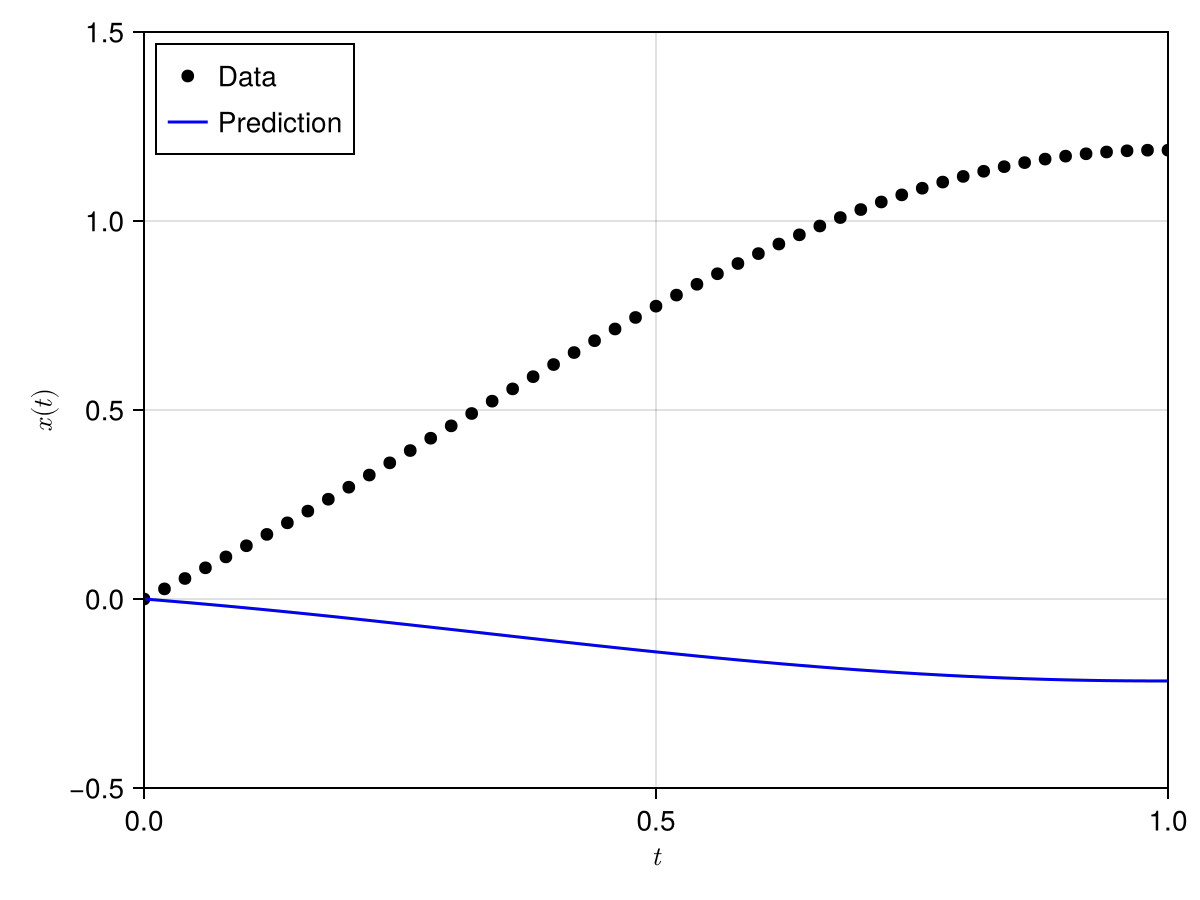

In [5]:
rmodel,_= RModel(tdata', parameters, layer_states)
C_model=rmodel[:]
C_model[1]=0.0 #boundary condition at t=0
C_model[n]=0.0 #boundary condition at t=1
prob=LinearProblem(A,C_model)
xpred=LinearSolve.solve(prob)

fig = Figure(backgroundcolor=:transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)",limits=(0, 1, -0.5, 1.5),backgroundcolor=:transparent)
#ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)",backgroundcolor=:transparent)
scatter!(ax,tdata,xdata,color=:black,label="Data")
lines!(ax,tdata,xpred,color=:blue,label="Prediction")
#save("../figures/06p05NeuralNetworkScientificModels02.png",fig)
axislegend(ax,position=:lt)
fig

Setting up the loss function. First we need to solve the matrix equation to compute the output of the equation.  Then we compare the computed $x_i$ with the data and then try to minimise the error (input-output)$^2$

In [6]:
function loss(p,xdata)
    rmodel,_= RModel(tdata', p, layer_states)
    C_model=rmodel[:]
    C_model[1]=0.0 #boundary condition at t=0
    C_model[n]=0.0 #boundary condition at t=1
    prob=LinearProblem(A,C_model)
    x=LinearSolve.solve(prob)
    return sum((x.-xdata).^2)
end

loss (generic function with 1 method)

In [7]:
loss(ComponentArray(parameters),Float32.(xdata))

46.548602275215195

In [8]:
function callback(state, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Current loss after $(length(losses)) iterations: $(losses[end])")
    end
    return false
end

callback (generic function with 1 method)

In [9]:
losses = Float64[]
adtype = AutoForwardDiff()
optf = OptimizationFunction(loss, adtype)

optprob = OptimizationProblem(optf,ComponentArray(parameters),Float32.(xdata))
sol=Optimization.solve(optprob,Adam(0.01f0),maxiters=20000, callback=callback)

Current loss after 50 iterations: 0.12447541952133179
Current loss after 100 iterations: 0.029774880036711693
Current loss after 150 iterations: 0.027336949482560158
Current loss after 200 iterations: 0.0271797813475132
Current loss after 250 iterations: 0.027008425444364548
Current loss after 300 iterations: 0.026823842898011208
Current loss after 350 iterations: 0.02662903256714344
Current loss after 400 iterations: 0.026426510885357857
Current loss after 450 iterations: 0.026218418031930923
Current loss after 500 iterations: 0.026006605476140976
Current loss after 550 iterations: 0.02579265832901001
Current loss after 600 iterations: 0.025577940046787262
Current loss after 650 iterations: 0.025363633409142494
Current loss after 700 iterations: 0.025150729343295097
Current loss after 750 iterations: 0.02494008094072342
Current loss after 800 iterations: 0.024732405319809914
Current loss after 850 iterations: 0.02452830784022808
Current loss after 900 iterations: 0.024328287690877914


retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-2.897652; -3.0137613; -3.212304;;], bias = Float32[1.1236358, -0.5607785, -2.2125382]), layer_2 = (weight = Float32[1.4458302 -0.8870457 -0.4309527; 0.8988777 0.16392587 2.4916034; -0.38843942 0.26756385 0.5624409], bias = Float32[-0.023426607, -1.9551435, -0.13032903]), layer_3 = (weight = Float32[0.99575216 -0.47737202 -0.048693318], bias = Float32[0.4204982]))

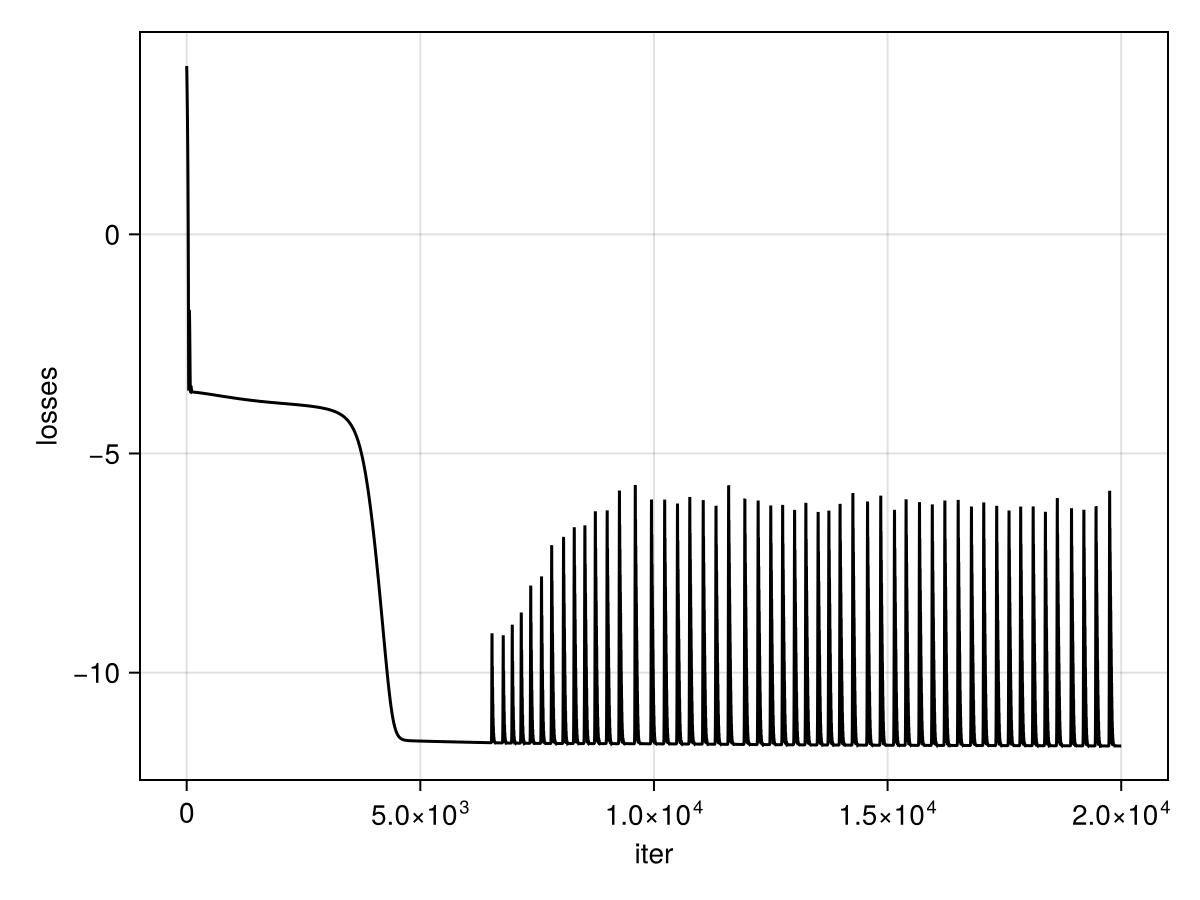

In [10]:
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = "iter", ylabel = "losses")
lines!(ax,log.(losses),color=:black)
fig

The loss have reduced to a very small value.  We will now use the found parameters for the Neural Network and use it to predict $x_i$.  

In [11]:
rmodel,_= RModel(tdata', sol.u, layer_states)
C_model=rmodel
C_model[1]=0.0
C_model[n]=0.0
prob=LinearProblem(A,C_model)
xmodel=LinearSolve.solve(prob)

retcode: Success
u: 51-element Vector{Float64}:
 6.749587555532344e-14
 0.026950340092517434
 0.054617052718406285
 0.08295600573834036
 0.11192182815075778
 0.14146797762091773
 0.1715468055620948
 0.20210961913035536
 0.23310673938490217
 0.26448755474810703
 ⋮
 1.1438821255209026
 1.1545155724391862
 1.1636801670865788
 1.1713540797727473
 1.1775185653477562
 1.1821579357561383
 1.1852595296849813
 1.1868136800875637
 1.1868136800875637

Compare with data.

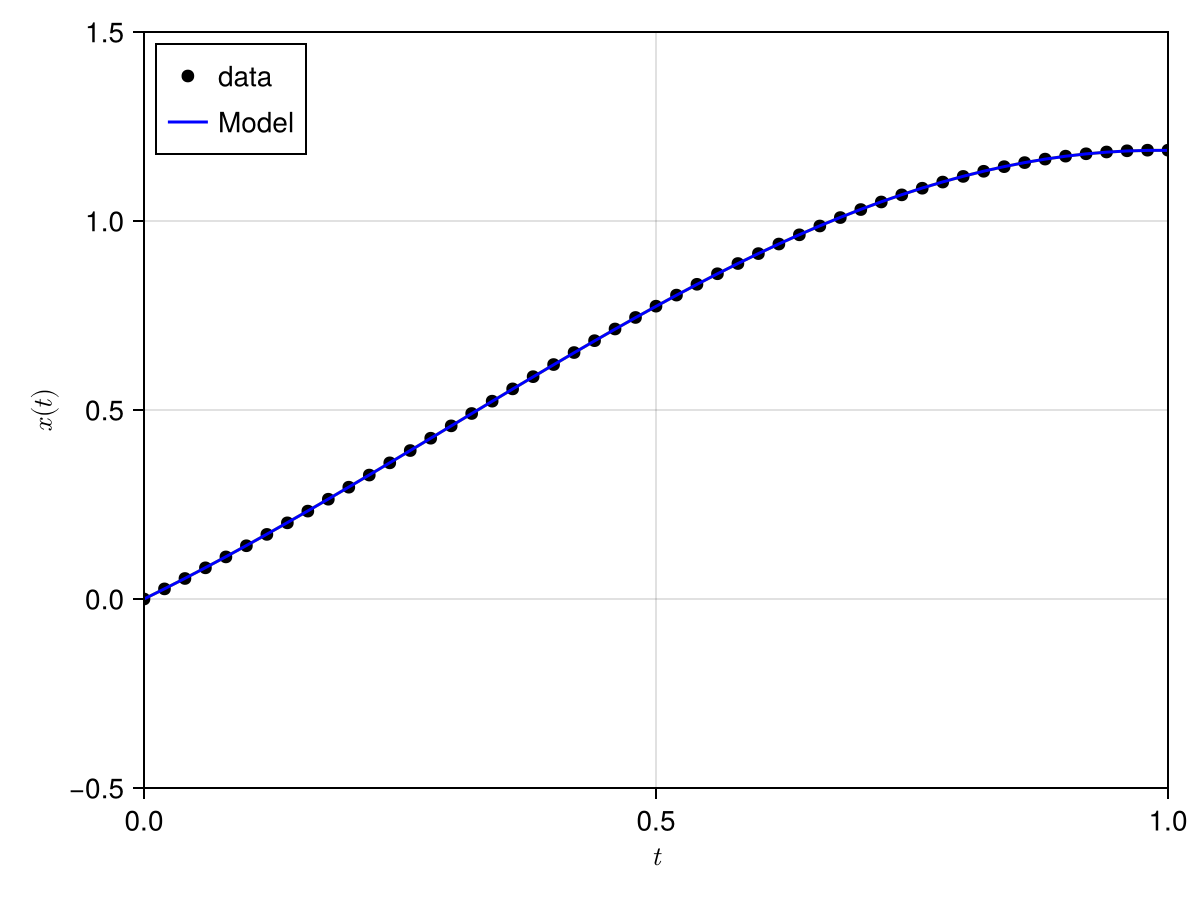

In [12]:
fig = Figure(backgroundcolor=:transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)",limits=(0, 1, -0.5, 1.5),backgroundcolor=:transparent)
scatter!(ax,tdata,xdata,color=:black,label="data")
lines!(ax,tdata,xmodel,color=:blue,label="Model")
#save("../figures/06p05NeuralNetworkScientificModels03.png",fig)
axislegend(ax,position=:lt)
fig

Pretty good agreement!

Plot what the Neural network found for $r(t)$.  To see how it looks like and compare with real $r(t)=2\exp(-t^2)$.

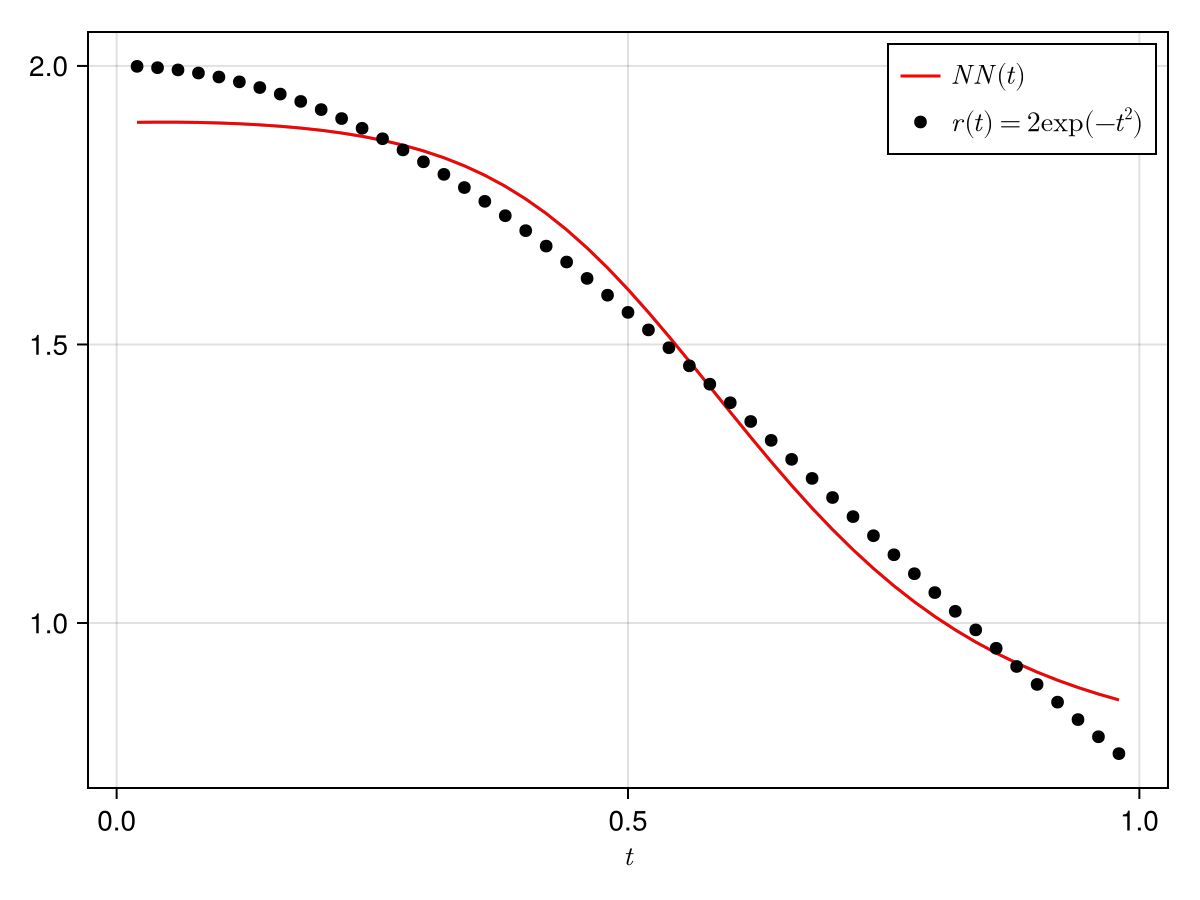

In [13]:
fig = Figure(backgroundcolor=:transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t",backgroundcolor=:transparent)
lines!(ax,tdata[2:end-1],rmodel[2:end-1],color=:red,label=L"NN(t)")
scatter!(ax,tdata[2:end-1],C_true[2:end-1],color=:black,label=L"r(t)=2\exp(-t^2)")
axislegend(ax,position=:rt)
save("../figures/06p05NeuralNetworkScientificModels04.png",fig)
fig

---

The main  advantage of this approach is that suppose someone comes and change the boundary condition at $t=0$ to $x(0)=1.0$.  You can easily change the boundary condition  and use the Neural Network (that approximates $r(t)$) to make this prediction.  

Let's compare the prediction of $x(t)$ with the true $r(t)=2\exp(-t^2)$ with the Neural network approximation for $r(t)$ with different values of $x(t=0)$.

In [14]:
C_true[1]=1.0
C_true[n]=0.0
prob=LinearProblem(A,C_true)
xdata=LinearSolve.solve(prob)


C_model=rmodel
C_model[1]=1.0
C_model[n]=0.0
prob=LinearProblem(A,C_model)
xmodel=LinearSolve.solve(prob)

retcode: Success
u: 51-element Vector{Float64}:
  0.999999999999961
  0.9339692409607807
  0.8672036242136503
  0.7998101093461726
  0.7318964973054056
  0.6635712528517337
  0.5949433216287097
  0.5261219416070626
  0.4572164485557391
  0.38833607507840046
  ⋮
 -1.2564459951390918
 -1.273588788990507
 -1.2883154681345257
 -1.300609636223415
 -1.31045808947787
 -1.317850895251231
 -1.3227814633745192
 -1.325246609435173
 -1.325246609435173

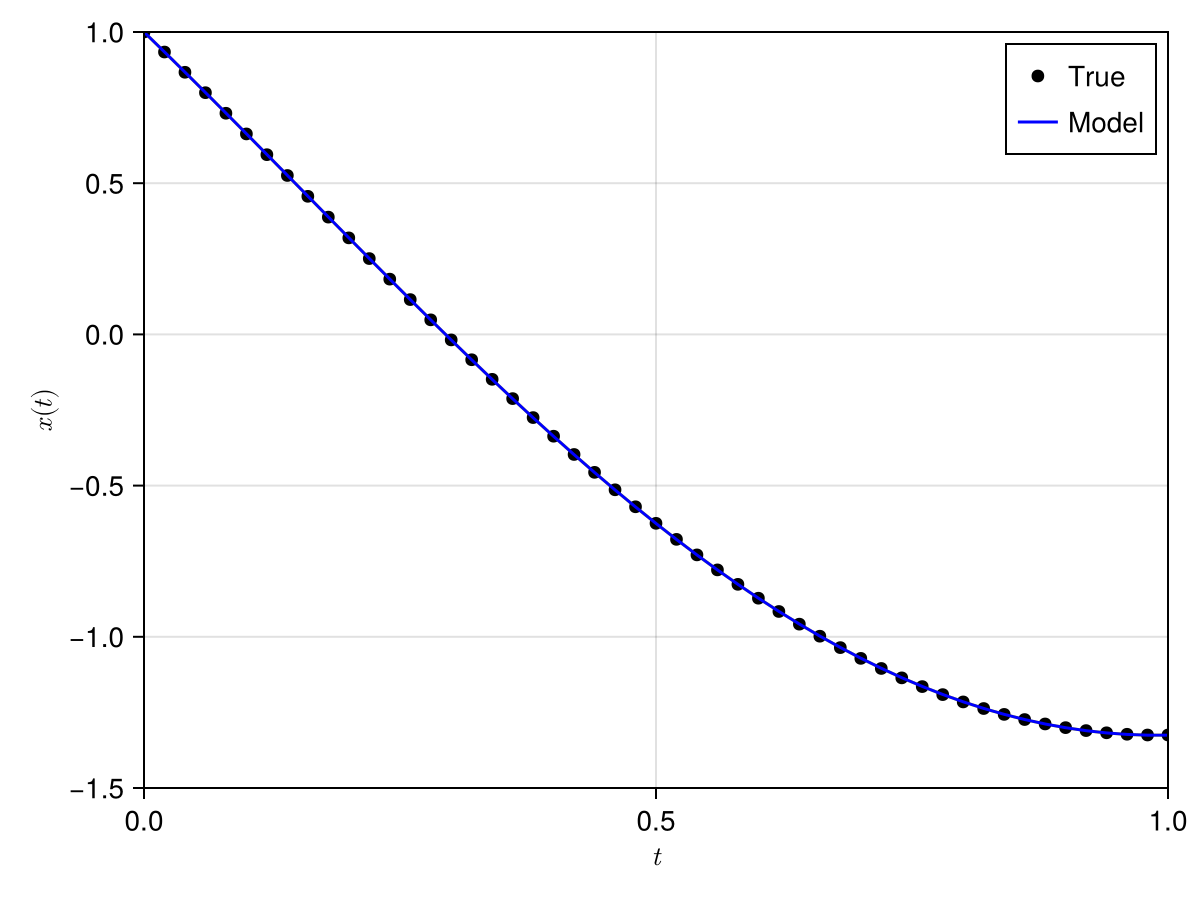

In [15]:
fig = Figure(backgroundcolor=:transparent)
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)",limits=(0,1,-1.5,1),backgroundcolor=:transparent)
scatter!(ax,tdata,xdata,color=:black,label="True")
lines!(ax,tdata,xmodel,color=:blue,label="Model")
save("../figures/06p05NeuralNetworkScientificModels05.png",fig)
axislegend(ax,position=:rt)

fig

So we have trained this model for $x(0)=0.0$ but used it to predict the $y$ when $x(0)$ changes to 1.0.  The prediction is still pretty good!

---

**Class Demo:** Use a Neural Network to find $r(t)$ from the file "Data07.csv".  Then use this Neural Network for $r(t)$ to predit the data in "Data08.csv", "Data09.csv", "Data10.csv"

---